# LIME: Local Interpretable Model-agnostic Explanations

Na podstawie artykułu: https://arxiv.org/pdf/1602.04938

---

<div style="text-align:center">
<img src="images/lime-example.png" width="750">
<p style="font-size:14px; text-align:center;">
Źródło: <a href="https://arxiv.org/pdf/1602.04938">
“Why Should I Trust You?” Explaining the Predictions of Any Classifier
</a>
</p>
</div>

Celem notebooka jest pokazanie, jak można wykorzystać framework LIME. LIME to klasyczna metoda post-hoc – pozwala na wyjaśnienie predykcji dowolnego klasyfikatora w sposób zrozumiały dla człowieka, bez konieczności ingerowania w jego wagi czy trenowania go od nowa.

W kolejnych częściach notebooka zostaną przedstawione:

* intuicja algorytmu LIME

* trening modelu klasyfikacji szeregów czasowych

* wizualizacja ważności cech

* interpretacja predykcji

## 1. Reprezentacje Interpretowalne (Interpretable Data Representations)

Kluczowym założeniem LIME jest rozróżnienie między **cechami używanymi przez model** a **cechami zrozumiałymi dla człowieka**.

* Niech $x \in \mathbb{R}^d$ będzie oryginalną reprezentacją instancji (np. gęste wektory embeddingów dla tekstu lub wartości RGB pikseli dla obrazu).
* Niech $x' \in \{0, 1\}^{d}$ będzie **reprezentacją interpretowalną**, czyli wektorem binarnym wskazującym na obecność lub brak jakiegoś zrozumiałego konceptu (np. informacja czy dane słowo występuje w tekście, lub czy dany "superpiksel" / fragment obrazu jest widoczny).

Wyjaśnienie modelu dla człowieka musi operować na przestrzeni $x'$, nawet jeśli sam algorytm uczył się na bardzo skomplikowanej przestrzeni $x$.

## 2. LIME: Wyjaśnianie pojedynczych predykcji

Celem LIME jest znalezienie interpretywnego modelu $g \in G$ (gdzie $G$ to klasa modeli łatwych do zrozumienia, np. modele liniowe lub drzewa decyzyjne), który **lokalnie** (w bezpośrednim otoczeniu badanej próbki) dobrze przybliża zachowanie złożonego modelu $f$.

Matematycznie, proces poszukiwania takiego wyjaśnienia (dla instancji $x$) definiuje się jako problem minimalizacji:

$$\xi(x) = \text{argmin}_{g \in G} \mathcal{L}(f, g, \pi_x) + \Omega(g)$$

Rozłóżmy to równanie na czynniki pierwsze:
* **$f(x)$** - prawdopodobieństwo (lub wynik) zwracany przez oryginalny model (czarną skrzynkę).
* **$g(x')$** - model interpretowalny, działający na zrozumiałych cechach. 
* **$\pi_x(z)$** - miara bliskości (np. odległość kosinusowa lub jądro Gaussa), definiująca jak bardzo próbka $z$ jest podobna do naszej instancji $x$. Definiuje ona "lokalne otoczenie".
* **$\mathcal{L}(f, g, \pi_x)$** - funkcja straty. Mierzy jak bardzo nasz prosty model $g$ myli się w stosunku do modelu $f$ w lokalnym otoczeniu wyznaczonym przez $\pi_x$. (To miara wierności - *local fidelity*).
* **$\Omega(g)$** - miara złożoności modelu interpretowalnego (np. głębokość drzewa lub liczba niezerowych wag w regresji). Im niższa wartość, tym model prostszy dla człowieka. (To miara interpretowalności).


<div style="text-align:center">
<img src="images/lime-intuition.png" width="750">
<p style="font-size:14px; text-align:center;">
Źródło: <a href="https://arxiv.org/pdf/1602.04938">
“Why Should I Trust You?” Explaining the Predictions of Any Classifier
</a>
</p>
</div>


### Sparse Linear Explanations
W praktyce (i w kodzie biblioteki), autorzy jako $G$ wybierają modele liniowe ($g(z') = w_g^T z'$), a jako metodę kontroli złożoności $\Omega(g)$ stosują limit maksymalnie $K$ niezerowych cech (np. regularyzacja L1 / Lasso).

**Procedura generowania sąsiedztwa i uczenia LIME:**
1. Weź instancję $x$ oraz jej interpretowalną reprezentację $x'$.
2. Wylosuj $N$ nowych instancji (perturbacji) poprzez losowe wyzerowanie części cech w $x'$ (otrzymując zbiór zaburzonych próbek $z'$).
3. Odtwórz każdą zaburzoną próbkę w jej oryginalnej przestrzeni ($z \in \mathbb{R}^d$). Na przykład: jeśli w kroku 2 usunęliśmy wybrane słowo z wektora binarnego, w oryginalnym tekście fizycznie usuwamy to słowo.
4. Użyj modelu $f$, aby przewidzieć wynik $f(z)$ dla każdej wygenerowanej próbki.
5. Naucz model liniowy $g$ na zbiorze wygenerowanych $z'$, minimalizując błąd przewidywań względem $f(z)$, przy czym próbki bardziej podobne do $x$ mają wyższe wagi $\pi_x(z)$.

## 3. Wyjaśnianie całego modelu: Submodular Pick (SP-LIME)

Wyjaśnienie pojedynczej predykcji pozwala zweryfikować konkretny przypadek, ale jak ocenić **cały model**, dysponując ograniczonym czasem eksperta? 

Użytkownik (np. analityk) jest w stanie przeanalizować ręcznie tylko określoną liczbę wyjaśnień, oznaczmy ją jako budżet $B$. Należy więc wybrać $B$ najbardziej reprezentatywnych, różnorodnych instancji do pokazania człowiekowi.

### Macierz Wyjaśnień i Ważność Cech
Mając dany zbiór instancji testowych $X$ o rozmiarze $n$, uruchamiamy LIME dla każdej z nich, uzyskując macierz wyjaśnień $\mathcal{W} \in \mathbb{R}^{n \times d'}$. Wiersze to instancje z danych testowych, a kolumny to cechy interpretowalne (np. słowa). Wartość $\mathcal{W}_{ij}$ to przypisana waga (ważność) cechy $j$ dla instancji $i$.

Obliczamy globalną ważność cechy $j$ (Feature Importance) jako sumę modułów jej wag na przestrzeni wszystkich wyjaśnień:
$$I_j = \sqrt{\sum_{i=1}^n |\mathcal{W}_{ij}|}$$

### Pokrycie (Coverage) i Optymalizacja Submodularna
Chcemy wybrać zbiór instancji $V$ ($|V| \le B$), taki, aby cechy obecne w tych instancjach miały jak największą sumaryczną globalną ważność. Aby jednak uniknąć pokazywania wciąż tych samych słów (np. 10 dokumentów wyjaśnianych tym samym słowem), wykorzystujemy tzw. pokrycie (coverage):

$$c(V, \mathcal{W}, I) = \sum_{j=1}^{d'} \mathbb{1}_{[\exists i \in V : \mathcal{W}_{ij} > 0]} I_j$$

Funkcja ta ma właściwość **submodularności** (efekt malejących zysków - dodanie instancji mającej to samo słowo co instancja już wybrana nie zwiększa funkcji celu). LIME używa **Algorytmu Zachłannego (Greedy)**, aby dokonać wyboru:

**Algorytm: Submodular Pick (SP-LIME)**
1. Uruchom LIME dla wszystkich instancji z badanego zbioru i utwórz macierz wag $\mathcal{W}$.
2. Oblicz globalne wagi cech $I_j$ ze wzoru powyżej.
3. Zainicjuj pusty zbiór na wybrane instancje: $V \leftarrow \emptyset$.
4. **Pętla (dopóki $|V| < B$):**
   - Dokonaj zachłannego wyboru nowej instancji $i$, która daje największy marginalny przyrost pokrycia:
     $i^* = \text{argmax}_{i} \, c(V \cup \{i\}, \mathcal{W}, I)$
   - Dodaj wybraną instancję: $V \leftarrow V \cup \{i^*\}$.
5. Zwróć wybrany podzbiór $V$ użytkownikowi.

<div style="text-align:center">
<img src="images/lime-submodular-pick.png" width="750">
<p style="font-size:14px; text-align:center;">
Źródło: <a href="https://arxiv.org/pdf/1602.04938">
“Why Should I Trust You?” Explaining the Predictions of Any Classifier
</a>
</p>
</div>

## 4. Przykład: analiza EKG

Będziemy pracować z datasetem zawierającym dane EKG. A szczególnie, będziemy klasyfikować EKG na cztery klasy (rytm zatokowy prawidłowy, migotanie przedsionków, częstoskurcz komorowy lub migotanie przedsionków i zawał mięśnia sercowego). Więcej informacji można znaleźć [tu](https://iopscience.iop.org/article/10.1088/1361-6579/abc960).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.metrics.pairwise import cosine_distances
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split

Najpierw wczytamy i przetworzymy dane:

In [2]:
ecg_train = pd.read_csv('data/ecg_train.csv', header=None)
ecg_test = pd.read_csv('data/ecg_test.csv', header=None)

ecg_train = ecg_train.replace([np.inf, -np.inf], np.nan).dropna()
ecg_test = ecg_test.replace([np.inf, -np.inf], np.nan).dropna()

In [3]:
ecg_train_x, ecg_train_y = ecg_train.drop(0, axis=1), ecg_train[0] - 1
ecg_test_x, ecg_test_y = ecg_test.drop(0, axis=1), ecg_test[0] - 1

Zdefiniujemy model i wytremujemy go:

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ECGCNN(nn.Module):
    def __init__(self, input_shape, num_classes):
        """
        input_shape: tuple time_steps, channels (exmaple 140, 1)
        num_classes: number of output classes
        """
        super(ECGCNN, self).__init__()
        time_steps, channels = input_shape

        self.conv1 = nn.Conv1d(in_channels=channels, out_channels=64, kernel_size=3)
        self.pool = nn.MaxPool1d(kernel_size=2)
        self.dropout = nn.Dropout(0.5)

        # Compute output length after conv and pooling
        conv_output_length = time_steps - 2  # kernel_size=3 reduces by 2
        pool_output_length = conv_output_length // 2  # MaxPool1d(pool_size=2)

        self.flattened_size = 64 * pool_output_length
        self.fc1 = nn.Linear(self.flattened_size, 100)
        self.fc2 = nn.Linear(100, num_classes)

    def forward(self, x):
        """
        x: Tensor of shape (batch_size, time_steps, channels)
        """
        if type(x) != torch.Tensor:
          x = torch.Tensor(x)

        x = x.permute(0, 2, 1)  # Change to (batch_size, channels, time_steps)
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = self.dropout(x)
        x = x.contiguous().view(x.size(0), -1)  # Flatten
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return torch.log_softmax(x, dim=1)  # Use CrossEntropyLoss, so no softmax here (pyTorch CrossEntropyLoss expects unbounded scores)

    def forward_probs(self, x):

      x = self.forward(x)
      return torch.exp(x)

In [5]:
input_shape = (ecg_train_x.shape[1], 1)
num_classes = np.unique(ecg_train_y).shape[0]

model = ECGCNN(input_shape, num_classes)

In [6]:
from tqdm import tqdm

def train_ecg_model(
        model, 
        train_dataset, 
        val_dataset, 
        num_epochs=10, 
        batch_size=64, 
        lr=1e-3, 
        device='cuda' if torch.cuda.is_available() else 'cpu'
    ):
    model.to(device)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = torch.nn.CrossEntropyLoss()

    all_val_losses = []
    all_train_losses = []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        all_preds = []
        all_targets = []

        for X_batch, y_batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * X_batch.size(0)
            _, predicted = outputs.max(1)
            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(y_batch.cpu().numpy())

        train_loss = running_loss / len(train_dataset)
        train_acc = (np.array(all_preds) == np.array(all_targets)).mean()
        train_f1 = f1_score(all_targets, all_preds, average='weighted')

        all_train_losses.append(train_loss)

        # Validation
        model.eval()
        val_loss = 0.0
        val_preds = []
        val_targets = []
        with torch.no_grad():
            for X_val, y_val in val_loader:
                X_val = X_val.to(device)
                y_val = y_val.to(device)
                outputs = model(X_val)
                loss = criterion(outputs, y_val)
                val_loss += loss.item() * X_val.size(0)
                _, predicted = outputs.max(1)
                val_preds.extend(predicted.cpu().numpy())
                val_targets.extend(y_val.cpu().numpy())

        val_loss /= len(val_dataset)
        val_acc = (np.array(val_preds) == np.array(val_targets)).mean()
        val_f1 = f1_score(val_targets, val_preds, average='weighted')

        print(f"Epoch {epoch+1}/{num_epochs} — "
              f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f}, F1: {train_f1:.4f} | "
              f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}, F1: {val_f1:.4f}")

        all_val_losses.append(val_loss)

    plt.plot(all_train_losses, label='Train loss')
    plt.plot(all_val_losses, label='Val loss')
    plt.title('Loss plot')
    plt.legend()


In [7]:
class ECGDataset(Dataset):
    def __init__(self, x, y):
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

In [8]:
ecg_train_x = np.expand_dims(ecg_train_x, axis=2)
x_tr, x_val, y_tr, y_val = train_test_split(ecg_train_x, ecg_train_y.values, test_size=0.2, random_state=42)

train_dataset = ECGDataset(x_tr, y_tr)
val_dataset = ECGDataset(x_val, y_val)

Epoch 1/8: 100%|██████████| 3/3 [00:00<00:00,  8.13it/s]


Epoch 1/8 — Train Loss: 2.0699, Acc: 0.3691, F1: 0.3500 | Val Loss: 0.7568, Acc: 0.6316, F1: 0.5984


Epoch 2/8: 100%|██████████| 3/3 [00:00<00:00, 12.40it/s]


Epoch 2/8 — Train Loss: 0.5022, Acc: 0.7987, F1: 0.8073 | Val Loss: 1.0099, Acc: 0.7368, F1: 0.7368


Epoch 3/8: 100%|██████████| 3/3 [00:00<00:00, 11.72it/s]


...

Epoch 6/8 — Train Loss: 0.0265, Acc: 0.9866, F1: 0.9866 | Val Loss: 0.0491, Acc: 0.9737, F1: 0.9731


Epoch 7/8: 100%|██████████| 3/3 [00:00<00:00, 12.21it/s]


Epoch 7/8 — Train Loss: 0.0012, Acc: 1.0000, F1: 1.0000 | Val Loss: 0.0710, Acc: 0.9737, F1: 0.9731


Epoch 8/8: 100%|██████████| 3/3 [00:00<00:00, 12.29it/s]


Epoch 8/8 — Train Loss: 0.0007, Acc: 1.0000, F1: 1.0000 | Val Loss: 0.0859, Acc: 0.9737, F1: 0.9731


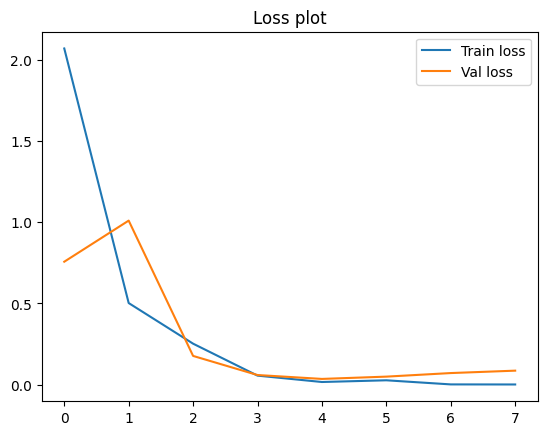

In [9]:
model = ECGCNN(input_shape=(ecg_train_x.shape[1], ecg_train_x.shape[2]), num_classes=len(set(ecg_train_y)))
train_ecg_model(model, train_dataset, val_dataset, num_epochs=8)

#### Interpretacja wyników

Wybierzemy losowy EKG i spróbujemy klasyfikować go:

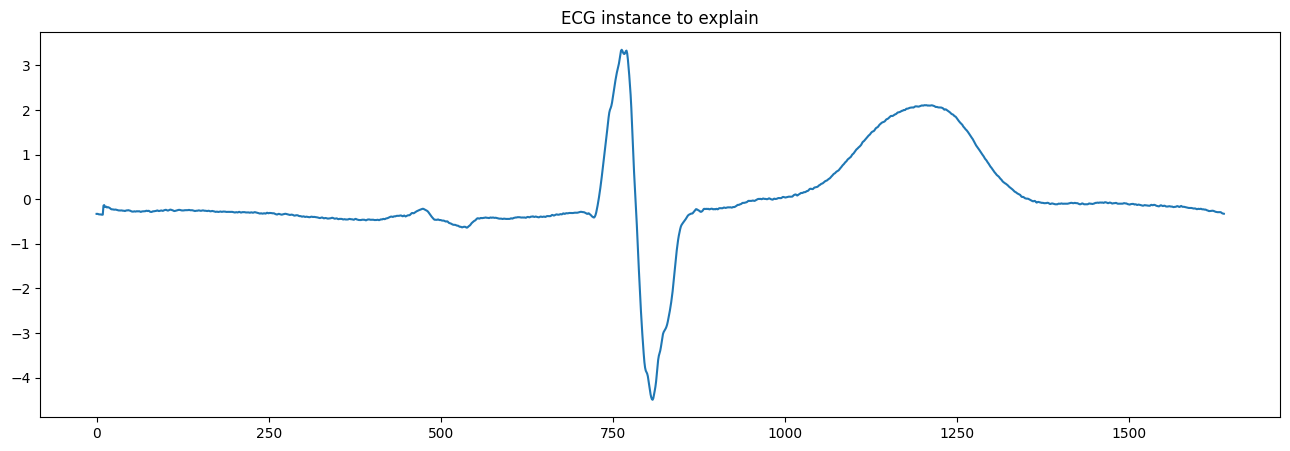

In [11]:
idx_ecg = 11
instance_ecg = ecg_test_x.iloc[idx_ecg, :].values

plt.figure(figsize=(16, 5))
plt.plot(instance_ecg)
plt.title('ECG instance to explain')

plt.show()

In [12]:
probability_vector = model.forward_probs(torch.Tensor(np.expand_dims(instance_ecg.reshape(1, -1), axis=2)))
print("Probability vector of the selected instance:", probability_vector)

predicted_class = torch.argmax(probability_vector).item()
print("Predicted Class for the selected instance:", predicted_class)

Probability vector of the selected instance: tensor([[2.0582e-13, 4.3340e-01, 5.6660e-01, 1.0958e-13]],
       grad_fn=<ExpBackward0>)
Predicted Class for the selected instance: 2


Został wykryty częstoskurcz komorowy.

Liczbę segmentów dobierzemy metodą „bliskiego spojrzenia". Bardziej poprawnym i formalnym podejściem jest dobór liczby segmentów w zależności od charakteru sygnału.

Segmenty uzyskamy w prosty sposób — dzieląc szereg na równe części. Mianowicie, dla szeregu o krokach czasowych dzielimy go na segmenty o stałej długości:

$ l = \lfloor \frac{L}{K} \rfloor$


gdzie L jest długością jednego segmentu.

Następnie wyznaczamy indeksy granic segmentów w następujący sposób:

$\text{Segment}_i = T[t_{i \cdot l} : t_{(i+1) \cdot l}], \quad i = 0, \dots, K-2$

Przy czym ostatni segment może zawierać „ogon":

$\text{Segment}_{K-1} = T[t_{(K-1) \cdot l} : t_L]$


Dzięki temu, nawet jeśli długość szeregu nie jest podzielna przez bez reszty, ostatni segment poprawnie obejmie wszystkie pozostałe punkty.

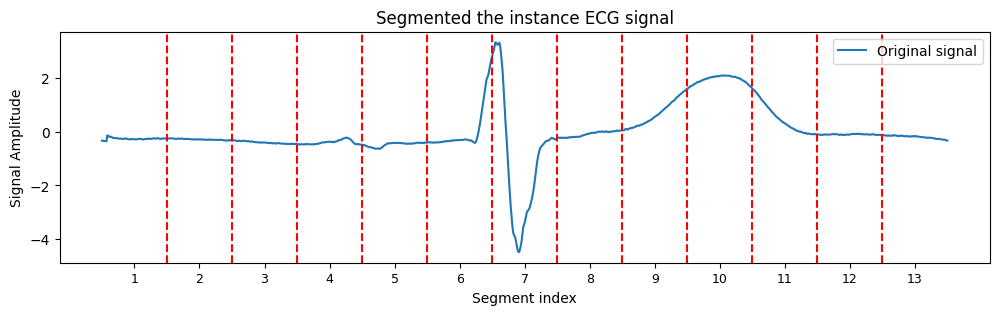

In [13]:
L = len(instance_ecg) # TS length
K = 13 # number of slices

l = L // K # slice width

# Segment start points
segment_edges = [i * l for i in range(K)] + [L]
# Segment centers
segment_centers = [(segment_edges[i] + segment_edges[i+1]) // 2 for i in range(K)]
# Segment labels
segment_labels = [f'{i+1}' for i in range(K)]

# Plot segmented instance
plt.figure(figsize=(12, 3))
plt.plot(instance_ecg, label='Original signal')

for i in range(1, K):
  plt.axvline(x=i*l, color='r', linestyle='--')

plt.xticks(ticks=segment_centers, labels=segment_labels, fontsize=9)
plt.title('Segmented the instance ECG signal')
plt.xlabel('Segment index')
plt.ylabel('Signal Amplitude')
plt.legend()
plt.show()

#### Generowanie obserwacji w sąsiedztwie

Obserwacje w sąsiedztwie oryginalnej instancji będziemy generować zgodnie z następującą strategią. Dla każdej zaburzonej wersji losowo wybieramy indeksy segmentów i modyfikujemy je za pomocą jednej z trzech strategii zastępowania:

* „mean" (średnia) — zastępujemy wszystkie wartości w segmencie średnią wartością tego segmentu;
* „noise" (szum) — zastępujemy wartości próbkami z rozkładu normalnego o średniej i odchyleniu standardowym danego segmentu;
* „zero" — ustawiamy wszystkie wartości w segmencie na zero.

Wszystkie zastąpienia są stosowane do fragmentów postaci:

$\text{Segment}_{i} = T[t_{(i) \cdot l} : t_{(i+1) \cdot l}]$

In [15]:
def split_series(series, num_slices):

    length = series.shape[0]
    slice_len = int(np.ceil(length / num_slices))
    return [(i * slice_len, min((i + 1) * slice_len, length)) for i in range(num_slices)]

slices = split_series(instance_ecg, 13)


def generate_perturbations(series, slices, num_samples, replacement="mean", pertub_power=0.2):
    perturbed = []
    masks = []
    for _ in range(num_samples):
        mask = np.ones(len(slices), dtype=int)
        idx_to_perub = np.random.choice(len(slices), size=int(len(slices)*pertub_power), replace=False)
        mask[idx_to_perub] = 0

        copy = series.copy()
        for i in idx_to_perub:
            start, end = slices[i]
            if replacement == "mean":
                copy[start:end] = np.mean(series[start:end])
            elif replacement == "zero":
                copy[start:end] = 0
            elif replacement == "noise":
                copy[start:end] = np.random.normal(series[start:end].mean(), series[start:end].std(), end - start)
        perturbed.append(copy)
        masks.append(mask)

    return np.array(perturbed), np.array(masks)


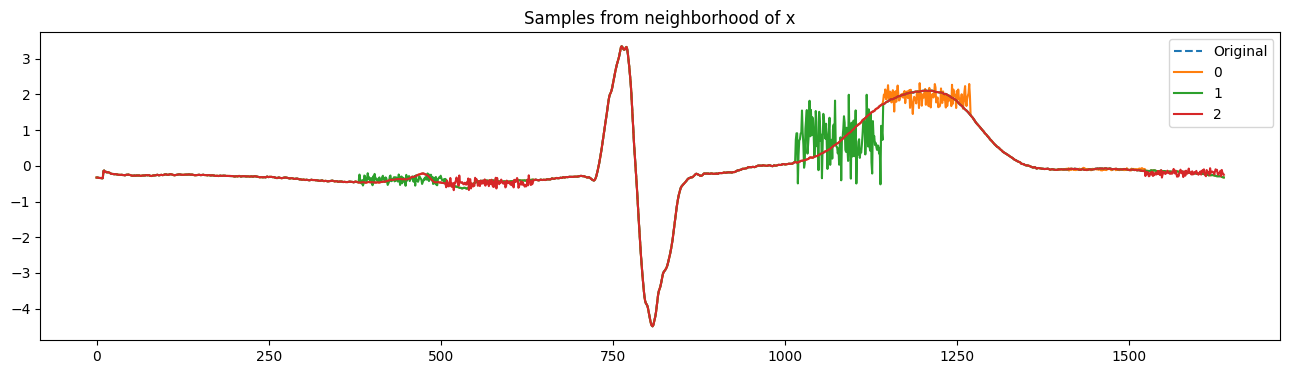

In [16]:
np.random.seed(42)
pertub, masks = generate_perturbations(instance_ecg, slices, 500, replacement="noise", pertub_power=0.2)

plt.figure(figsize=(16, 4))
plt.plot(instance_ecg, label='Original', linestyle='--')
[plt.plot(pertub[i], label=f'{i}') for i in range(0, 3)]
plt.legend()
plt.title('Samples from neighborhood of x')

plt.show()

Uwaga: Na tym etapie uzyskujemy również maski binarne. Do trenowania modelu interpretowalnego zbiór danych będzie reprezentowany za pomocą cech binarnych dla każdego segmentu. Cecha przyjmuje wartość 1, jeśli odpowiadający jej segment jest zachowany, oraz 0, jeśli został zaburzony. Podejście to jest również stosowane w implementacji LIME dla danych tekstowych, gdzie obecność lub nieobecność słów jest kodowana w analogiczny sposób.

#### Trenowanie modelu interpretowalnego w sąsiedztwie

Zamiast rozwiązywać oryginalne zadanie predykcji, skupiamy się teraz na tym, aby model interpretowalny naśladował zachowanie modelu czarnoskrzynkowego. Oznacza to, że trenujemy model interpretowalny tak, aby odtwarzał te same predykcje co model oryginalny.
Podczas trenowania uwzględniamy wagę każdej obserwacji: im bliżej oryginalnej instancji znajduje się zaburzona próbka, tym większą wagę powinna mieć w procesie uczenia.

In [17]:
# Probabilities for all observations from the neighborhood
probs = np.exp(model(np.expand_dims(pertub, axis=2)).detach().numpy())

# Calculate the distances
distances = cosine_distances(pertub, instance_ecg.reshape(1, -1)).ravel()

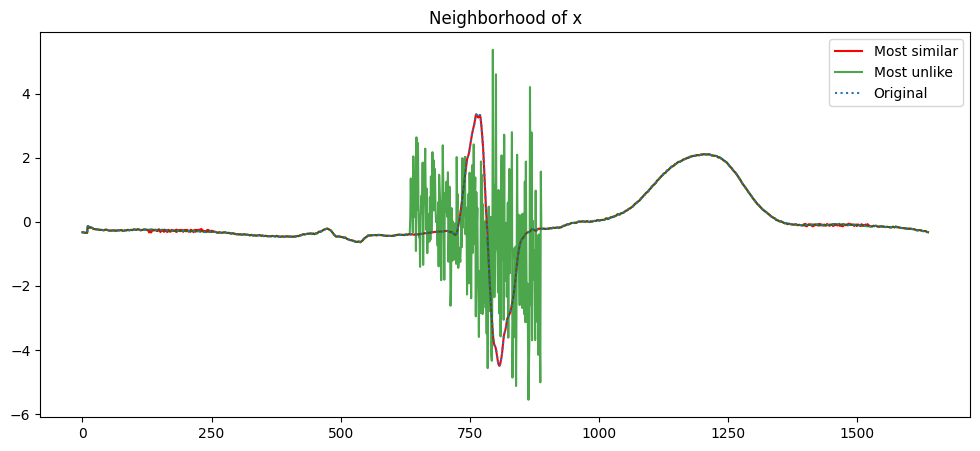

In [18]:
similar_inst_idx = np.argmin(distances)
most_similar = pertub[similar_inst_idx]

unlike_inst_idx = np.argmax(distances)
most_unlike = pertub[unlike_inst_idx]

plt.figure(figsize=(12, 5))
plt.plot(most_similar, label='Most similar', color='r')
plt.plot(most_unlike, label='Most unlike', alpha=0.7, color='g')
plt.plot(instance_ecg, label='Original', linestyle=':')
plt.legend()
plt.title('Neighborhood of x')

plt.show()

In [19]:
from sklearn.linear_model import Ridge
import numpy as np

def train_lime_ridge(perturbations, predictions, distances, target_class, alpha=1.0, kernel_width=0.25):
    # LIME exponential kernel
    weights = np.exp(- (distances ** 2) / (kernel_width ** 2))

    # target
    y = predictions[:, target_class]

    # simple Ridge-regression train
    model = Ridge(alpha=alpha)
    model.fit(perturbations, y, sample_weight=weights)

    return model.coef_, model.intercept_, model.score(perturbations, y, sample_weight=weights)

w, b, score = train_lime_ridge(masks, probs, distances, 0, alpha=.8)

/var/folders/0d/t9srvbn17p59nl_nd33spxg00000gn/T/ipykernel_35959/1895853727.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap(cmap)(norm(weights))


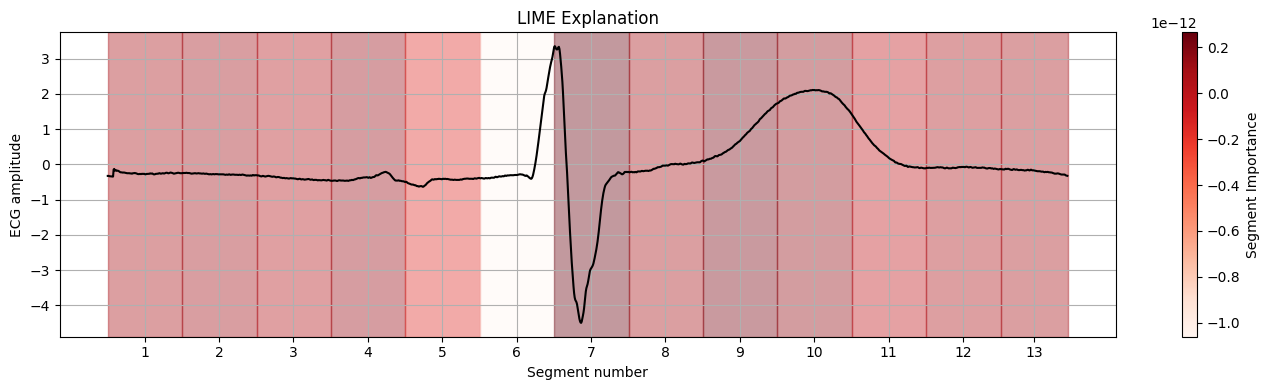

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

def visualize_segment_weights(series, slices, weights, title='LIME Explanation', cmap='Reds'):
    assert len(slices) == len(weights)

    norm = plt.Normalize(vmin=min(weights), vmax=max(weights))
    colors = cm.get_cmap(cmap)(norm(weights))

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(series, color='black', linewidth=1.5, label='Time Series')

    segment_centers = []
    segment_labels = []

    for i, ((start, end), color) in enumerate(zip(slices, colors)):
        ax.axvspan(start, end, color=color, alpha=0.4)
        center = (start + end) // 2
        segment_centers.append(center)
        segment_labels.append(f'{i+1}')

    # Добавим подписи по оси X — номера сегментов
    ax.set_xticks(segment_centers)
    ax.set_xticklabels(segment_labels, rotation=0)
    ax.set_xlabel('Segment number')

    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    plt.colorbar(sm, label='Segment Importance', ax=ax)
    plt.title(title)
    plt.ylabel('ECG amplitude')
    plt.grid(True)
    plt.tight_layout()
    plt.show()


visualize_segment_weights(instance_ecg, slices, w, title='LIME Explanation')

Aby uzyskać nieco dokładniejszy obraz ważności cech, możemy użyć reprezentacji w postaci wykresu słupkowego.

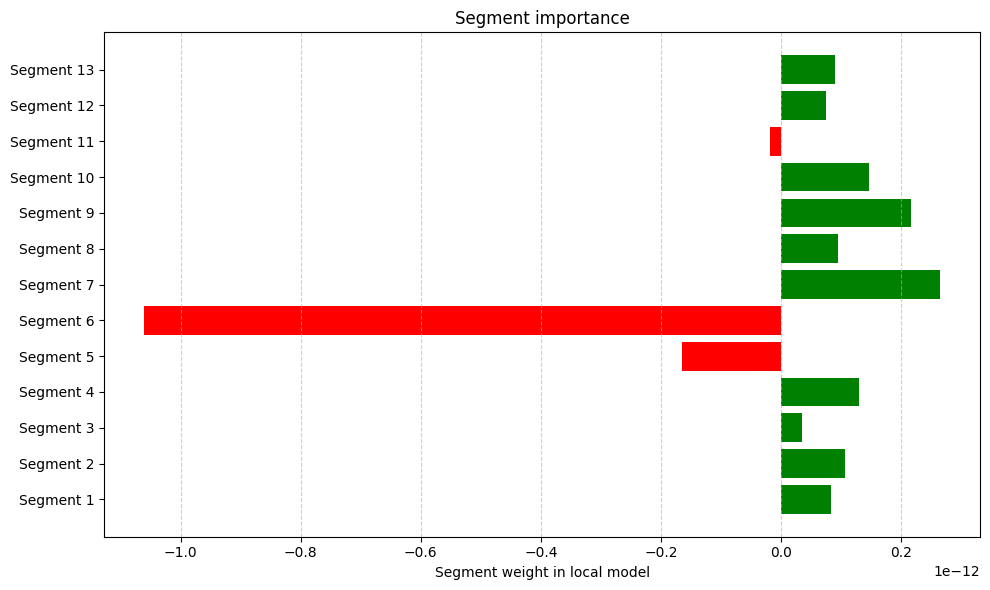

In [21]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['green' if val >= 0 else 'red' for val in w]
segment_labels = [f'Segment {i+1}' for i in range(len(w))]

ax.barh(range(len(w)), w, color=colors)
ax.set_yticks(range(len(w)))
ax.set_yticklabels(segment_labels)
ax.set_xlabel('Segment weight in local model')
ax.set_title('Segment importance')
plt.grid(True, axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Zadanie 3 (obowiązkowe): Analiza zbioru 20 Newsgroups

Wytrenuj model klasyfikacyjny Random Forest na zbiorze danych 20 Newsgroups (wybierz kategorie 'alt.atheism', 'soc.religion.christian'). Następnie, wykorzystując framework LIME, zbadaj, na podstawie jakich cech (słów) model podejmuje decyzje dla poszczególnych predykcji. Jakie wnioski dotyczące jakości wyuczonych reguł oraz wiarygodności modelu można wyciągnąć z tych wyjaśnień?

In [4]:
import numpy as np
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from lime.lime_text import LimeTextExplainer


categories = ['alt.atheism', 'soc.religion.christian']
newsgroups_train = fetch_20newsgroups(subset='train', categories=categories)
newsgroups_test = fetch_20newsgroups(subset='test', categories=categories)
class_names = ['Atheism', 'Christian']